# ML Final Project — Image Classification: Anime / Cartoon / Human

**Student:** Yosef Pasha  
**ID (last 4):** 2572

---

## AI Tools Used
Claude AI (Anthropic) was used for:
1. Code structure and best-practices guidance
2. Feature extraction implementations (HOG, colour histogram, pixel)
3. Visualisation function design
4. Dataset loading and train/test split logic
5. Comments and documentation

---

## Project Overview

This project builds a **3-class image classifier** (Anime / Cartoon / Human) using a **neural network implemented from scratch** with NumPy — no Keras, no PyTorch.

The pipeline has 6 parts:

| Part | Description |
|------|-------------|
| 1 | Data loading and visualisation |
| 2 | Feature engineering (HOG, colour histogram, pixels) |
| 3 | ANN implementation sanity check |
| 4 | Baseline model training (all 3 features concatenated) |
| 5 | Test-set evaluation |
| 6 | Bonus: grid search + k-fold CV, feature combinations |


## Setup — Imports and Configuration

All hyperparameters and constants are defined here in one place so they are easy to change.

In [16]:
import warnings
warnings.filterwarnings("ignore")

import os
import ast
import itertools

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from PIL import Image
from tqdm import tqdm
from skimage.feature import hog
from skimage.color import rgb2gray
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, confusion_matrix, classification_report

print("All imports OK")

All imports OK


In [17]:
# ── Configuration ─────────────────────────────────────────────────────────────

IMG_SIZE   = (64, 64)   # every image is resized to this before processing
TEST_SIZE  = 0.20       # 80 % train, 20 % test
RANDOM_STATE = 42

DATA_ROOT_CANDIDATES = [
    "Data",                          # same directory as this notebook
    "/content/Data",                 # Google Colab root
    "/content/drive/MyDrive/Data",   # Google Colab + Drive
]

# Default model hyperparameters (Parts 4 & 5)
DEFAULT_HIDDEN_LAYERS = [256, 128]
DEFAULT_LEARNING_RATE = 0.01
DEFAULT_N_EPOCHS      = 50
DEFAULT_BATCH_SIZE    = 32

# Feature-engineering configs (Part 6b) — individual + combinations
FE_CONFIGS = [
    {"method": "hog",             "params": {"orientations": 8}},
    {"method": "hog",             "params": {"orientations": 12}},
    {"method": "color_histogram", "params": {"bins": 32}},
    {"method": "color_histogram", "params": {"bins": 64}},
    {"method": "pixels",          "params": {}},
    # Combinations
    {"method": "combined", "params": {"methods": ["hog", "color_histogram"]}},
    {"method": "combined", "params": {"methods": ["hog", "pixels"]}},
    {"method": "combined", "params": {"methods": ["color_histogram", "pixels"]}},
    {"method": "combined", "params": {"methods": ["hog", "color_histogram", "pixels"]}},
]

# Hyperparameter grid (Part 6c)
HP_GRID = {
    "hidden_layers":  [[128], [256, 128], [512, 256], [256, 128, 64]],
    "learning_rate":  [0.001, 0.01, 0.1],
    "batch_size":     [16, 32, 64],
}

CV_N_SPLITS = 5    # number of folds
CV_N_EPOCHS = 30   # shorter epoch count during experiments (faster)

---
## Part 1 — Data Loading

Images are loaded from a folder structure where each sub-folder represents a class:
```
Data/
  Anime/
  Cartoon/
  Human/
```

Every image is:
1. Converted to RGB (handles grayscale or RGBA files).
2. Resized to **64×64 pixels** to give the ANN a fixed-size input.
3. Normalised to the range **[0, 1]** (dividing pixel values by 255).

The dataset is split into **80 % training / 20 % test** using **stratified sampling** so that every class is represented proportionally in both sets.

In [20]:
# ── Data loading functions ────────────────────────────────────────────────────

def find_data_root(candidates=None):
    """Return the first existing path from candidates."""
    for path in (candidates or DATA_ROOT_CANDIDATES):
        if os.path.isdir(path):
            print(f"Data folder found: {path}")
            return path
    raise FileNotFoundError(
        "Could not find the 'Data' folder. "
        "Adjust DATA_ROOT_CANDIDATES at the top of this notebook."
    )


def _load_images(base_path, img_size=IMG_SIZE):
    """Walk base_path/class_name/ and load all images as float32 arrays in [0,1]."""
    class_names  = sorted(d for d in os.listdir(base_path)
                           if os.path.isdir(os.path.join(base_path, d)))
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}
    idx_to_class = {idx: name for name, idx in class_to_idx.items()}

    X, y = [], []
    print(f"Classes: {class_names}")
    for class_name in class_names:
        folder = os.path.join(base_path, class_name)
        files  = [f for f in os.listdir(folder)
                  if f.lower().endswith((".jpg", ".jpeg", ".png", ".gif"))]
        print(f"  {class_name}: {len(files)} images")
        for fname in tqdm(files, desc=class_name, leave=False):
            try:
                img = Image.open(os.path.join(folder, fname)).convert("RGB")
                img = img.resize(img_size, Image.LANCZOS)
                X.append(np.array(img, dtype=np.float32) / 255.0)
                y.append(class_to_idx[class_name])
            except Exception:
                pass

    return (np.array(X, dtype=np.float32), np.array(y, dtype=np.int32),
            class_names, class_to_idx, idx_to_class)


def load_and_split(data_root):
    """Load all images and return a stratified 80/20 train/test split."""
    print("Loading images…")
    X_all, y_all, class_names, class_to_idx, idx_to_class = _load_images(data_root)
    print(f"\nTotal: {len(X_all)} images  |  {len(class_names)} classes")

    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=TEST_SIZE, stratify=y_all, random_state=RANDOM_STATE
    )

    print(f"\nSplit (stratified 80/20):")
    for idx, name in idx_to_class.items():
        print(f"  {name:12s}  train={int((y_train==idx).sum()):4d}  "
              f"test={int((y_test==idx).sum()):4d}")

    class_info = {"names": class_names, "to_idx": class_to_idx, "to_name": idx_to_class}
    return X_train, X_test, y_train, y_test, class_info


def show_samples(X, y, idx_to_class, n=5, title="Samples"):
    """Display n random sample images with their class labels."""
    indices = np.random.choice(len(X), size=min(n, len(X)), replace=False)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    for ax, idx in zip(axes, indices):
        ax.imshow(X[idx])
        ax.set_title(idx_to_class[y[idx]], fontsize=9)
        ax.axis("off")
    plt.suptitle(title, fontweight="bold")
    plt.tight_layout()
    plt.show()

Data folder found: Data
Loading images…
Classes: ['anime', 'cartoon', 'human']
  anime: 3004 images


  cartoon: 2913 images


  human: 3000 images



Total: 8917 images  |  3 classes

Split (stratified 80/20):
  anime         train=2403  test= 601
  cartoon       train=2330  test= 583
  human         train=2400  test= 600

Training samples:


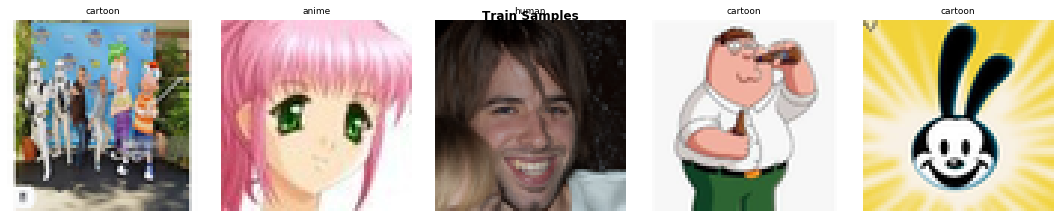

Test samples:


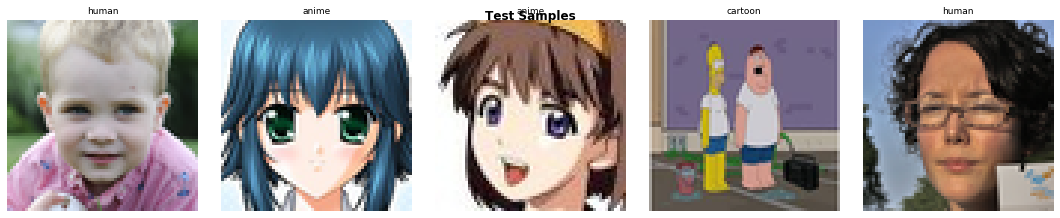

In [21]:
# ── Run Part 1 ────────────────────────────────────────────────────────────────
data_root = find_data_root()
X_train, X_test, y_train, y_test, class_info = load_and_split(data_root)

print("\nTraining samples:")
show_samples(X_train, y_train, class_info["to_name"], n=5, title="Train Samples")
print("Test samples:")
show_samples(X_test,  y_test,  class_info["to_name"], n=5, title="Test Samples")

---
## Part 2 — Feature Engineering

Raw pixel arrays are too high-dimensional and noisy to feed directly into a shallow ANN. Instead we extract three complementary hand-crafted feature descriptors:

### 1. HOG — Histogram of Oriented Gradients
HOG captures **edge direction distributions** in local image patches (cells). It is invariant to colour and small spatial shifts, making it excellent at encoding **shape information** (e.g. the silhouette of a face vs. a cartoon character). For a 64×64 image with default parameters (8 orientations, 8×8 pixel cells, 2×2 block normalisation) it produces ~1,568 features.

### 2. Colour Histogram
A normalised histogram is computed per RGB channel and concatenated → **3 × bins** features (e.g. 96 features for 32 bins). Anime and cartoon images often have very different colour palettes from real human photographs, making this a strong discriminating signal.

### 3. Pixel Features
Each image is downscaled to 32×32 and flattened → **3,072 features**. This is a simple spatial baseline that preserves rough layout information.

In [25]:
# ── Feature extraction functions ──────────────────────────────────────────────

def extract_hog_features(images, orientations=8, pixels_per_cell=(8, 8),
                         cells_per_block=(2, 2)):
    """HOG: captures edge direction distributions. ~1,568 features for 64x64 images."""
    features = []
    for img in tqdm(images, desc="HOG", leave=False):
        feat = hog(rgb2gray(img), orientations=orientations,
                   pixels_per_cell=pixels_per_cell,
                   cells_per_block=cells_per_block, visualize=False)
        features.append(feat)
    return np.array(features, dtype=np.float32)


def extract_color_histogram_features(images, bins=32):
    """Normalised RGB histograms. 3 × bins features."""
    features = []
    for img in tqdm(images, desc="ColorHist", leave=False):
        hist_parts = []
        for ch in range(3):
            h, _ = np.histogram(img[:, :, ch], bins=bins, range=(0.0, 1.0))
            hist_parts.extend(h / (h.sum() + 1e-8))
        features.append(np.array(hist_parts, dtype=np.float32))
    return np.array(features, dtype=np.float32)


def extract_pixel_features(images, target_size=(32, 32)):
    """Flattened resized pixels. target_size^2 × 3 features."""
    features = []
    for img in tqdm(images, desc="Pixels", leave=False):
        small = np.array(
            Image.fromarray((img * 255).astype(np.uint8))
                 .resize(target_size, Image.LANCZOS),
            dtype=np.float32,
        ) / 255.0
        features.append(small.flatten())
    return np.array(features, dtype=np.float32)


FEATURE_METHODS = {
    "hog":             extract_hog_features,
    "color_histogram": extract_color_histogram_features,
    "pixels":          extract_pixel_features,
}


def extract_combined_features(images, methods=None):
    """Concatenate multiple extractors into one feature vector."""
    if methods is None:
        methods = ["hog", "color_histogram", "pixels"]
    parts = [FEATURE_METHODS[m](images) for m in methods]
    return np.hstack(parts)


FEATURE_METHODS["combined"] = extract_combined_features


def extract_features(images, method="hog", **kwargs):
    """Dispatch to the chosen feature extractor."""
    if method not in FEATURE_METHODS:
        raise ValueError(f"Unknown method '{method}'. Choose from: {list(FEATURE_METHODS)}")
    return FEATURE_METHODS[method](images, **kwargs)

In [26]:
# ── Visualisation functions ───────────────────────────────────────────────────

def visualize_hog(images, labels, idx_to_class, n=3):
    """Show original images alongside their HOG gradient visualisations."""
    indices = np.random.choice(len(images), size=n, replace=False)
    fig, axes = plt.subplots(n, 2, figsize=(8, n * 3))
    for row, idx in enumerate(indices):
        gray = rgb2gray(images[idx])
        _, hog_img = hog(gray, orientations=8, pixels_per_cell=(8, 8),
                         cells_per_block=(2, 2), visualize=True)
        axes[row, 0].imshow(images[idx])
        axes[row, 0].set_title(f"Original — {idx_to_class[labels[idx]]}")
        axes[row, 0].axis("off")
        axes[row, 1].imshow(hog_img, cmap="gray")
        axes[row, 1].set_title("HOG features")
        axes[row, 1].axis("off")
    plt.suptitle("HOG Feature Visualisation", fontweight="bold")
    plt.tight_layout()
    plt.show()


def visualize_color_histogram(images, labels, idx_to_class, n=3):
    """Show original images alongside their normalised RGB channel histograms."""
    indices = np.random.choice(len(images), size=n, replace=False)
    fig, axes = plt.subplots(n, 2, figsize=(10, n * 3))
    for row, idx in enumerate(indices):
        axes[row, 0].imshow(images[idx])
        axes[row, 0].set_title(f"Original — {idx_to_class[labels[idx]]}")
        axes[row, 0].axis("off")
        for ch, color in enumerate(["red", "green", "blue"]):
            h, bins = np.histogram(images[idx, :, :, ch], bins=32, range=(0, 1))
            axes[row, 1].plot(bins[:-1], h / h.sum(), color=color, alpha=0.7, label=color.upper())
        axes[row, 1].set_title("RGB Histogram")
        axes[row, 1].set_xlabel("Pixel value")
        axes[row, 1].set_ylabel("Normalised frequency")
        axes[row, 1].legend()
    plt.suptitle("Colour Histogram Visualisation", fontweight="bold")
    plt.tight_layout()
    plt.show()


def visualize_pixel_features(images, labels, idx_to_class, n=3, target_size=(32, 32)):
    """Show original images alongside the 32×32 downscaled version used as pixel features."""
    indices = np.random.choice(len(images), size=n, replace=False)
    fig, axes = plt.subplots(n, 2, figsize=(8, n * 3))
    for row, idx in enumerate(indices):
        small = np.array(
            Image.fromarray((images[idx] * 255).astype(np.uint8))
                 .resize(target_size, Image.LANCZOS),
            dtype=np.float32,
        ) / 255.0
        axes[row, 0].imshow(images[idx])
        axes[row, 0].set_title(f"Original — {idx_to_class[labels[idx]]}")
        axes[row, 0].axis("off")
        axes[row, 1].imshow(small)
        axes[row, 1].set_title(f"Pixel features ({target_size[0]}×{target_size[1]})")
        axes[row, 1].axis("off")
    plt.suptitle("Pixel Feature Visualisation", fontweight="bold")
    plt.tight_layout()
    plt.show()

HOG visualisation — training set


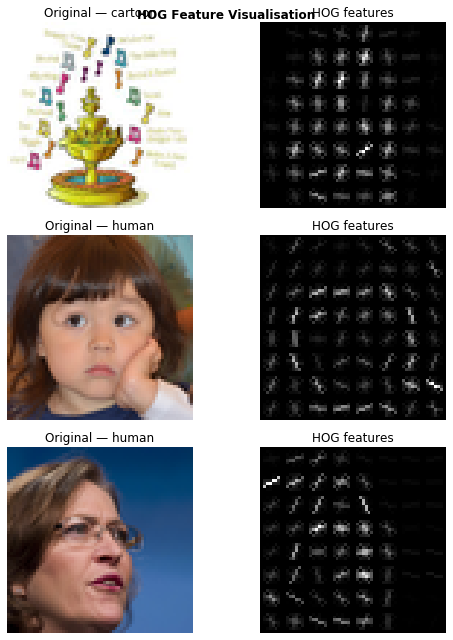

HOG visualisation — test set


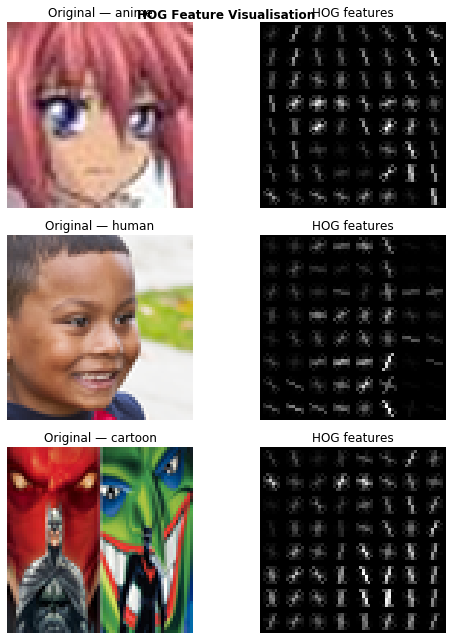

Colour histogram — training set


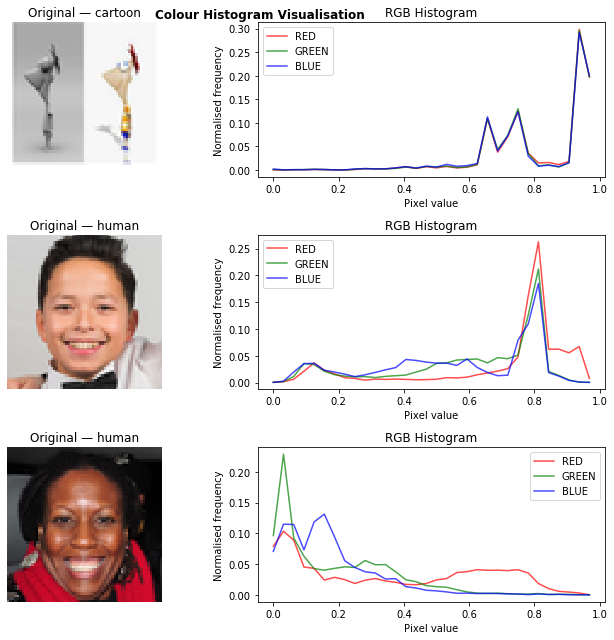

Colour histogram — test set


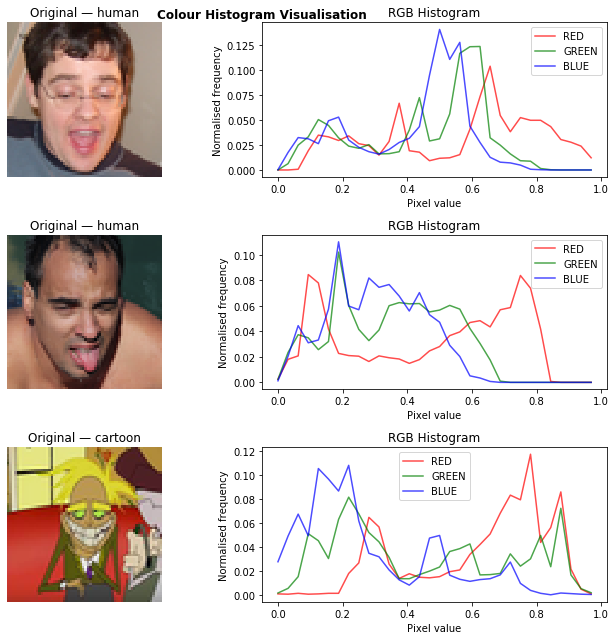

Pixel features — training set


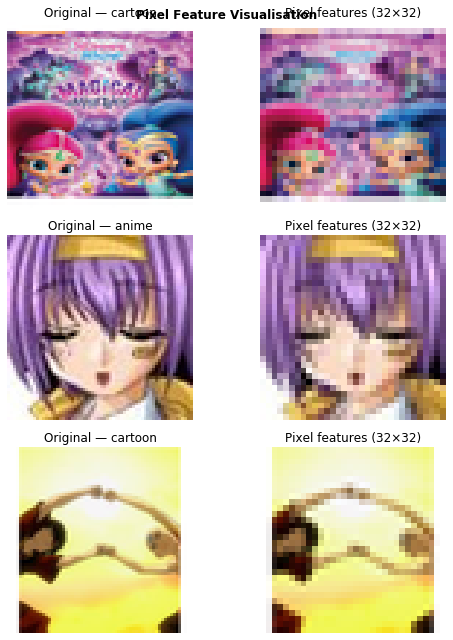

Pixel features — test set


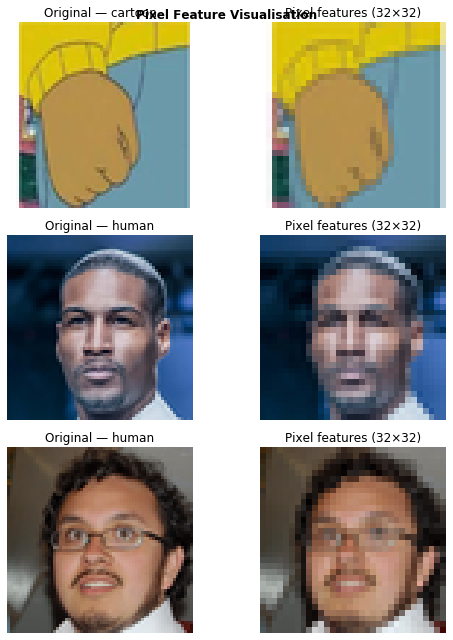

In [27]:
# ── Run Part 2 ────────────────────────────────────────────────────────────────
idx_to_name = class_info["to_name"]

print("HOG visualisation — training set")
visualize_hog(X_train, y_train, idx_to_name)

print("HOG visualisation — test set")
visualize_hog(X_test, y_test, idx_to_name)

print("Colour histogram — training set")
visualize_color_histogram(X_train, y_train, idx_to_name)

print("Colour histogram — test set")
visualize_color_histogram(X_test, y_test, idx_to_name)

print("Pixel features — training set")
visualize_pixel_features(X_train, y_train, idx_to_name)

print("Pixel features — test set")
visualize_pixel_features(X_test, y_test, idx_to_name)

---
## Part 3 — ANN Implementation (Sanity Check)

The neural network is implemented **entirely with NumPy** — no deep learning framework is used.

### Architecture
```
Input → [Hidden Layer 1 (ReLU)] → ... → [Hidden Layer N (ReLU)] → Output (Softmax)
```

### Key Design Choices

| Component | Choice | Why |
|-----------|--------|-----|
| Hidden activation | **ReLU** | Avoids vanishing gradients, trains faster than sigmoid/tanh |
| Output activation | **Softmax** | Converts logits to a probability distribution over classes |
| Loss | **Categorical cross-entropy** | Standard for multi-class classification |
| Optimiser | **Mini-batch SGD** | Efficient balance between full-batch and online learning |
| Weight init | **He initialisation** | Keeps gradient variance stable across layers with ReLU |

### Backpropagation Simplification
Because we use Softmax + cross-entropy, the output-layer gradient simplifies elegantly:  
$$\delta_{\text{output}} = \hat{y} - y_{\text{true}}$$
This avoids computing the Jacobian of the softmax explicitly.

### Sanity Check
Before training on real data we verify the implementation on 200 random dummy samples. If the loss decreases consistently, the forward pass, backward pass and weight updates are all correct.

In [28]:
# ── ANN implementation ────────────────────────────────────────────────────────

class ANN:
    """
    Feedforward neural network for multi-class classification.
    Built from scratch using NumPy only.
    """

    def __init__(self, hidden_layers=(256, 128), learning_rate=0.01,
                 n_epochs=50, batch_size=32, random_state=42):
        self.hidden_layers  = list(hidden_layers)
        self.learning_rate  = learning_rate
        self.n_epochs       = n_epochs
        self.batch_size     = batch_size
        self.random_state   = random_state
        self.weights        = []
        self.biases         = []
        self.training_history = []
        self._fitted        = False

    def _init_weights(self, n_features, n_classes):
        """He initialisation: W ~ N(0, sqrt(2/fan_in)). Optimal for ReLU layers."""
        np.random.seed(self.random_state)
        sizes = [n_features] + self.hidden_layers + [n_classes]
        self.weights = [
            np.random.randn(sizes[i], sizes[i+1]) * np.sqrt(2.0 / sizes[i])
            for i in range(len(sizes) - 1)
        ]
        self.biases = [np.zeros((1, sizes[i+1])) for i in range(len(sizes) - 1)]

    @staticmethod
    def _relu(z):      return np.maximum(0, z)

    @staticmethod
    def _relu_grad(z): return (z > 0).astype(float)

    @staticmethod
    def _softmax(z):
        e = np.exp(z - z.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

    def _forward(self, X):
        """Full forward pass; returns output probabilities and cached intermediates."""
        A_list, Z_list = [X], []
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            z = A_list[-1] @ W + b
            Z_list.append(z)
            is_output = (i == len(self.weights) - 1)
            A_list.append(self._softmax(z) if is_output else self._relu(z))
        return A_list[-1], Z_list, A_list

    def _backward(self, y_ohe, Z_list, A_list):
        """Backprop via chain rule. Output gradient = ŷ - y (softmax+CE simplification)."""
        m = A_list[0].shape[0]
        n_layers = len(self.weights)
        dW = [None] * n_layers
        db = [None] * n_layers
        delta = A_list[-1] - y_ohe
        for i in range(n_layers - 1, -1, -1):
            dW[i] = A_list[i].T @ delta / m
            db[i] = delta.sum(axis=0, keepdims=True) / m
            if i > 0:
                delta = (delta @ self.weights[i].T) * self._relu_grad(Z_list[i-1])
        return dW, db

    def fit(self, X, y, verbose=True):
        """Train with mini-batch SGD."""
        n, n_features = X.shape
        n_classes = len(np.unique(y))
        self._init_weights(n_features, n_classes)
        y_ohe = np.eye(n_classes)[y]
        self.training_history = []

        for epoch in range(self.n_epochs):
            shuffle = np.random.permutation(n)
            epoch_loss, n_batches = 0.0, 0
            for start in range(0, n, self.batch_size):
                sl  = slice(start, start + self.batch_size)
                X_b = X[shuffle[sl]]
                y_b = y_ohe[shuffle[sl]]
                out, Z, A = self._forward(X_b)
                epoch_loss += -np.mean(y_b * np.log(np.clip(out, 1e-10, 1.0)))
                n_batches  += 1
                dW, db = self._backward(y_b, Z, A)
                for i in range(len(self.weights)):
                    self.weights[i] -= self.learning_rate * dW[i]
                    self.biases[i]  -= self.learning_rate * db[i]
            avg_loss = epoch_loss / n_batches
            self.training_history.append(avg_loss)
            if verbose and (epoch + 1) % 10 == 0:
                print(f"  Epoch {epoch+1:3d}/{self.n_epochs}  loss={avg_loss:.4f}")

        self._fitted = True
        return self

    def predict_proba(self, X):
        out, _, _ = self._forward(X)
        return out

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def score(self, X, y):
        return float((self.predict(X) == y).mean())

    def plot_training_history(self, title="Training Loss"):
        plt.figure(figsize=(8, 4))
        plt.plot(self.training_history, linewidth=2, color="steelblue")
        plt.title(title, fontweight="bold")
        plt.xlabel("Epoch")
        plt.ylabel("Cross-Entropy Loss")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

Training ANN on 200 dummy samples (3 classes, 50 features)…
  Epoch  10/20  loss=0.3907
  Epoch  20/20  loss=0.3386
Dummy-data accuracy: 0.4150


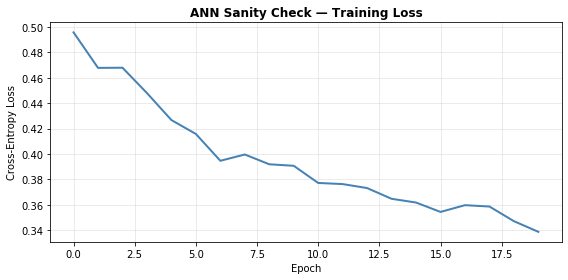

ANN implementation verified — loss is decreasing consistently.


In [29]:
# ── Run Part 3: Sanity check ──────────────────────────────────────────────────
np.random.seed(42)
X_dummy = np.random.randn(200, 50)
y_dummy = np.random.randint(0, 3, 200)

print("Training ANN on 200 dummy samples (3 classes, 50 features)…")
ann_check = ANN(hidden_layers=[32, 16], learning_rate=0.01, n_epochs=20, batch_size=32)
ann_check.fit(X_dummy, y_dummy)

print(f"Dummy-data accuracy: {ann_check.score(X_dummy, y_dummy):.4f}")
ann_check.plot_training_history(title="ANN Sanity Check — Training Loss")
print("ANN implementation verified — loss is decreasing consistently.")

---
## Part 4 — Baseline Model Training

### All Three Features Concatenated

Instead of using only one feature type, Part 4 extracts **all three descriptors** and concatenates them into a single feature vector:

| Feature | Size (default params) | Captures |
|---------|----------------------|----------|
| HOG | ~1,568 | Shape / edge structure |
| Colour histogram | 96 (3×32 bins) | Colour palette distribution |
| Pixel features | 3,072 (32×32×3) | Spatial layout |
| **Combined** | **~4,736** | **All of the above** |

Combining features gives the network richer, complementary information — the ANN can learn which aspects are most discriminative for each class.

### Feature Scaling
Before training, features are standardised to **zero mean and unit variance** using `StandardScaler`. This is important because:
- HOG values, histogram frequencies, and pixel intensities are on different scales.
- Neural networks with SGD converge much faster when all inputs are on a similar scale.
- The scaler is fitted **only on training data** to prevent data leakage.

In [30]:
# ── Preprocessing function ────────────────────────────────────────────────────

def preprocess_features(X_train_feats, X_test_feats):
    """
    Fit StandardScaler on training features only, then apply to both splits.
    Prevents data leakage: test statistics never influence the scaler.
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_feats)
    X_test_scaled  = scaler.transform(X_test_feats)
    return X_train_scaled, X_test_scaled, scaler

Extracting all features (HOG + Colour Histogram + Pixel)…


Feature shapes — train: (7133, 4736)  |  test: (1784, 4736)

Training ANN  [256, 128]  lr=0.01  epochs=50…
  Epoch  10/50  loss=0.0003
  Epoch  20/50  loss=0.0001
  Epoch  30/50  loss=0.0001
  Epoch  40/50  loss=0.0001
  Epoch  50/50  loss=0.0000


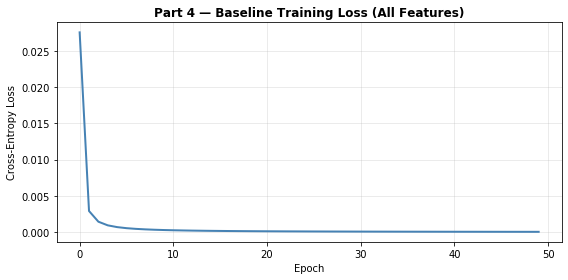

In [31]:
# ── Run Part 4: extract all 3 features and train baseline ANN ─────────────────
print("Extracting all features (HOG + Colour Histogram + Pixel)…")
X_tr_feats = extract_features(X_train, method="combined")
X_te_feats = extract_features(X_test,  method="combined")

X_tr_scaled, X_te_scaled, scaler = preprocess_features(X_tr_feats, X_te_feats)
print(f"Feature shapes — train: {X_tr_scaled.shape}  |  test: {X_te_scaled.shape}")

ann = ANN(
    hidden_layers = DEFAULT_HIDDEN_LAYERS,
    learning_rate = DEFAULT_LEARNING_RATE,
    n_epochs      = DEFAULT_N_EPOCHS,
    batch_size    = DEFAULT_BATCH_SIZE,
)
print(f"\nTraining ANN  {DEFAULT_HIDDEN_LAYERS}  lr={DEFAULT_LEARNING_RATE}  "
      f"epochs={DEFAULT_N_EPOCHS}…")
ann.fit(X_tr_scaled, y_train)
ann.plot_training_history(title="Part 4 — Baseline Training Loss (All Features)")

---
## Part 5 — Test-Set Evaluation

We evaluate the baseline model on the held-out test set using:

1. **Prediction display** — Show the first 5 test images with the model's predicted class and per-class confidence bars. Green = predicted, red = true (when wrong).

2. **Confusion matrix** — A heatmap showing which classes the model confuses with each other.

3. **Macro-average F1 score** — The primary metric. Computed as the mean F1 across all classes, giving equal weight to each class regardless of its size. This is appropriate when class balance matters.

In [32]:
# ── Evaluation functions ──────────────────────────────────────────────────────

def show_predictions(X_raw, X_scaled, y_true, model, idx_to_class, n=5):
    """Display n test samples with raw image and per-class confidence bars."""
    y_pred  = model.predict(X_scaled[:n])
    y_proba = model.predict_proba(X_scaled[:n])
    class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
    for i in range(n):
        correct = y_pred[i] == y_true[i]
        axes[i, 0].imshow(X_raw[i])
        axes[i, 0].set_title(f"True: {idx_to_class[y_true[i]]}")
        axes[i, 0].axis("off")

        bar_colors = [
            "green"     if j == y_pred[i] else
            "tomato"    if j == y_true[i] else
            "lightgrey"
            for j in range(len(class_names))
        ]
        axes[i, 1].barh(class_names, y_proba[i],
                        color=bar_colors, edgecolor="black", alpha=0.85)
        axes[i, 1].set_xlim(0, 1)
        axes[i, 1].set_xlabel("Confidence")
        axes[i, 1].set_title(
            f"Predicted: {idx_to_class[y_pred[i]]}  {'✓' if correct else '✗'}",
            color="green" if correct else "red", fontweight="bold"
        )
        for j, val in enumerate(y_proba[i]):
            axes[i, 1].text(val + 0.02, j, f"{val:.3f}", va="center", fontsize=8)

    plt.suptitle("Test Set Predictions (first 5 samples)", fontweight="bold")
    plt.tight_layout()
    plt.show()


def evaluate_model(y_true, y_pred, class_names, title="Confusion Matrix"):
    """Print macro F1, classification report, and show confusion matrix heatmap."""
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    print(f"\nMacro-average F1 score : {macro_f1:.4f}")
    print("\nPer-class classification report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=ax)
    ax.set_title(f"{title}\nMacro F1 = {macro_f1:.4f}", fontweight="bold")
    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

    return macro_f1

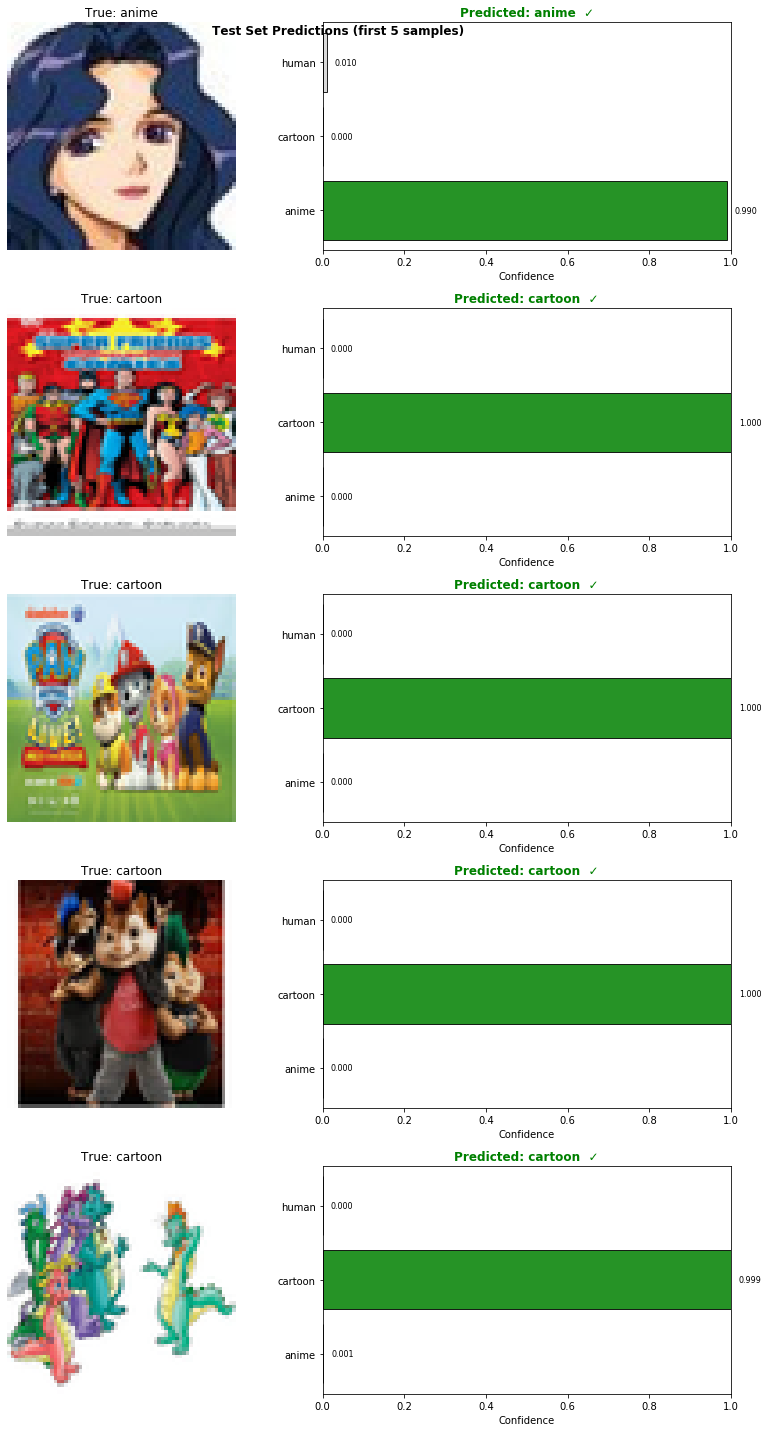


Macro-average F1 score : 0.9961

Per-class classification report:
              precision    recall  f1-score   support

       anime       0.99      1.00      1.00       601
     cartoon       1.00      1.00      1.00       583
       human       1.00      0.99      0.99       600

    accuracy                           1.00      1784
   macro avg       1.00      1.00      1.00      1784
weighted avg       1.00      1.00      1.00      1784



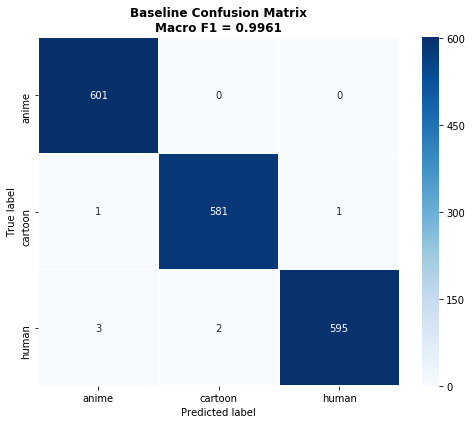

In [33]:
# ── Run Part 5: evaluate baseline model ──────────────────────────────────────
show_predictions(X_test, X_te_scaled, y_test, ann, class_info["to_name"], n=5)

y_pred      = ann.predict(X_te_scaled)
baseline_f1 = evaluate_model(y_test, y_pred, class_info["names"],
                              title="Baseline Confusion Matrix")

---
## Part 6 — Bonus Experiments

### 6a — K-Fold Cross-Validation Framework

All experiments use **5-fold stratified k-fold cross-validation** to get reliable performance estimates from the training data alone (without touching the test set).

In each fold:
1. The training set is split into 4 folds (training) + 1 fold (validation).
2. A fresh `StandardScaler` is fitted **only on the 4 training folds** to prevent leakage.
3. The model is trained and evaluated on the validation fold.
4. The macro F1 is recorded.

The final score is the **mean ± std across all 5 folds**. A low std means the model is stable regardless of which fold is held out.

### 6b — Feature Engineering Experiments

We test **9 feature configurations** — 5 individual methods and **4 combinations**:

| # | Method | Params | Size |
|---|--------|--------|------|
| 1 | HOG | 8 orientations | ~1,568 |
| 2 | HOG | 12 orientations | ~2,352 |
| 3 | Colour histogram | 32 bins | 96 |
| 4 | Colour histogram | 64 bins | 192 |
| 5 | Pixels | 32×32 | 3,072 |
| 6 | **HOG + Colour Hist** | default | ~1,664 |
| 7 | **HOG + Pixels** | default | ~4,640 |
| 8 | **Colour Hist + Pixels** | default | 3,168 |
| 9 | **HOG + Colour Hist + Pixels** | default | ~4,736 |

The best configuration found here is used in Part 6c.

### 6c — Hyperparameter Search

Using the best feature extractor from 6b, we run a **Cartesian product grid search** over:
- Hidden layers: `[128]`, `[256,128]`, `[512,256]`, `[256,128,64]`
- Learning rate: `0.001`, `0.01`, `0.1`
- Batch size: `16`, `32`, `64`

Total: **4 × 3 × 3 = 36 combinations**, each evaluated with 5-fold CV.

### 6g — Final Model

The best feature config (6b) + best hyperparameters (6c) are combined to retrain a final model on the full training set with 50 epochs. This is then evaluated on the test set.

In [34]:
# ── 6a: K-fold cross-validation core ─────────────────────────────────────────

def _kfold_score(X_raw_feats, y, model_class, model_params, n_splits=CV_N_SPLITS):
    """
    Stratified k-fold CV. StandardScaler fitted inside each fold (no leakage).
    Returns mean_f1, std_f1.
    """
    skf    = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_raw_feats, y), start=1):
        scaler  = StandardScaler()
        X_tr    = scaler.fit_transform(X_raw_feats[tr_idx])
        X_va    = scaler.transform(X_raw_feats[va_idx])
        model   = model_class(**model_params)
        model.fit(X_tr, y[tr_idx], verbose=False)
        fold_f1 = f1_score(y[va_idx], model.predict(X_va), average="macro")
        scores.append(fold_f1)
        print(f"    Fold {fold}/{n_splits}: F1 = {fold_f1:.4f}")

    mean, std = float(np.mean(scores)), float(np.std(scores))
    print(f"    → Mean F1: {mean:.4f}  ±  {std:.4f}\n")
    return mean, std

In [35]:
# ── 6b: Feature engineering experiments (individual + combinations) ────────────

def run_fe_experiments(X_train_raw, y_train, model_class, fixed_model_params):
    """
    Test every FE_CONFIGS entry (individual features + combinations)
    with 5-fold CV. Returns DataFrame sorted by mean_f1.
    """
    rows = []
    print(f"Testing {len(FE_CONFIGS)} feature-engineering configurations…\n")

    for i, cfg in enumerate(FE_CONFIGS, start=1):
        print(f"  [{i}/{len(FE_CONFIGS)}]  method={cfg['method']}  params={cfg['params']}")
        feats = extract_features(X_train_raw, method=cfg["method"], **cfg["params"])
        mean, std = _kfold_score(feats, y_train, model_class, fixed_model_params)
        rows.append({
            "method":     cfg["method"],
            "params":     str(cfg["params"]),
            "n_features": feats.shape[1],
            "mean_f1":    mean,
            "std_f1":     std,
        })

    df = pd.DataFrame(rows).sort_values("mean_f1", ascending=False).reset_index(drop=True)
    return df


def best_fe_config(fe_df):
    """Return (method_str, params_dict) of the top-ranked FE configuration."""
    row = fe_df.iloc[0]
    return row["method"], ast.literal_eval(row["params"])

In [36]:
# ── Run Part 6b ───────────────────────────────────────────────────────────────
fixed_params = {
    "hidden_layers": DEFAULT_HIDDEN_LAYERS,
    "learning_rate": DEFAULT_LEARNING_RATE,
    "n_epochs":      CV_N_EPOCHS,
    "batch_size":    DEFAULT_BATCH_SIZE,
    "random_state":  42,
}

fe_df = run_fe_experiments(X_train, y_train, ANN, fixed_params)
print("\nResults (sorted by mean F1):")
print(fe_df.to_string(index=False))

best_method, best_fe_params = best_fe_config(fe_df)
print(f"\nBest FE method : {best_method}  params={best_fe_params}")

Testing 9 feature-engineering configurations…

  [1/9]  method=hog  params={'orientations': 8}


    Fold 1/5: F1 = 0.9916
    Fold 2/5: F1 = 0.9937
    Fold 3/5: F1 = 0.9965
    Fold 4/5: F1 = 0.9916
    Fold 5/5: F1 = 0.9902
    → Mean F1: 0.9927  ±  0.0022

  [2/9]  method=hog  params={'orientations': 12}


    Fold 1/5: F1 = 0.9930
    Fold 2/5: F1 = 0.9937
    Fold 3/5: F1 = 0.9944
    Fold 4/5: F1 = 0.9937
    Fold 5/5: F1 = 0.9916
    → Mean F1: 0.9933  ±  0.0009

  [3/9]  method=color_histogram  params={'bins': 32}


    Fold 1/5: F1 = 0.8553
    Fold 2/5: F1 = 0.8623
    Fold 3/5: F1 = 0.8664
    Fold 4/5: F1 = 0.8643
    Fold 5/5: F1 = 0.8647
    → Mean F1: 0.8626  ±  0.0039

  [4/9]  method=color_histogram  params={'bins': 64}


    Fold 1/5: F1 = 0.8526
    Fold 2/5: F1 = 0.8625
    Fold 3/5: F1 = 0.8552
    Fold 4/5: F1 = 0.8796
    Fold 5/5: F1 = 0.8482
    → Mean F1: 0.8596  ±  0.0110

  [5/9]  method=pixels  params={}


    Fold 1/5: F1 = 0.9824
    Fold 2/5: F1 = 0.9859
    Fold 3/5: F1 = 0.9901
    Fold 4/5: F1 = 0.9867
    Fold 5/5: F1 = 0.9845
    → Mean F1: 0.9859  ±  0.0026

  [6/9]  method=combined  params={'methods': ['hog', 'color_histogram']}


    Fold 1/5: F1 = 0.9937
    Fold 2/5: F1 = 0.9929
    Fold 3/5: F1 = 0.9951
    Fold 4/5: F1 = 0.9923
    Fold 5/5: F1 = 0.9923
    → Mean F1: 0.9932  ±  0.0011

  [7/9]  method=combined  params={'methods': ['hog', 'pixels']}


    Fold 1/5: F1 = 0.9965
    Fold 2/5: F1 = 0.9979
    Fold 3/5: F1 = 0.9986
    Fold 4/5: F1 = 0.9965
    Fold 5/5: F1 = 0.9965
    → Mean F1: 0.9972  ±  0.0009

  [8/9]  method=combined  params={'methods': ['color_histogram', 'pixels']}


    Fold 1/5: F1 = 0.9845
    Fold 2/5: F1 = 0.9866
    Fold 3/5: F1 = 0.9887
    Fold 4/5: F1 = 0.9845
    Fold 5/5: F1 = 0.9873
    → Mean F1: 0.9863  ±  0.0016

  [9/9]  method=combined  params={'methods': ['hog', 'color_histogram', 'pixels']}


    Fold 1/5: F1 = 0.9951
    Fold 2/5: F1 = 0.9965
    Fold 3/5: F1 = 0.9979
    Fold 4/5: F1 = 0.9951
    Fold 5/5: F1 = 0.9993
    → Mean F1: 0.9968  ±  0.0016


Results (sorted by mean F1):
  mean_f1           method  n_features                                             params    std_f1
 0.997189         combined        4640                     {'methods': ['hog', 'pixels']}  0.000885
 0.996768         combined        4736  {'methods': ['hog', 'color_histogram', 'pixels']}  0.001642
 0.993259              hog        2352                               {'orientations': 12}  0.000948
 0.993244         combined        1664            {'methods': ['hog', 'color_histogram']}  0.001054
 0.992684              hog        1568                                {'orientations': 8}  0.002200
 0.986330         combined        3168         {'methods': ['color_histogram', 'pixels']}  0.001642
 0.985923           pixels        3072                                                 {}  0.002564
 0.862

In [37]:
# ── 6c: Hyperparameter grid search ───────────────────────────────────────────

def run_hp_experiments(X_raw_feats, y_train, model_class, n_epochs=CV_N_EPOCHS):
    """
    Cartesian product of HP_GRID evaluated with 5-fold CV.
    Returns DataFrame sorted by mean_f1.
    """
    combos = list(itertools.product(
        HP_GRID["hidden_layers"],
        HP_GRID["learning_rate"],
        HP_GRID["batch_size"],
    ))
    print(f"Testing {len(combos)} hyperparameter combinations…\n")

    rows = []
    for i, (hl, lr, bs) in enumerate(combos, start=1):
        params = {
            "hidden_layers": hl,
            "learning_rate": lr,
            "n_epochs":      n_epochs,
            "batch_size":    bs,
            "random_state":  42,
        }
        print(f"  [{i}/{len(combos)}]  hidden={hl}  lr={lr}  bs={bs}")
        mean, std = _kfold_score(X_raw_feats, y_train, model_class, params)
        rows.append({
            "hidden_layers": str(hl),
            "learning_rate": lr,
            "batch_size":    bs,
            "mean_f1":       mean,
            "std_f1":        std,
        })

    df = pd.DataFrame(rows).sort_values("mean_f1", ascending=False).reset_index(drop=True)
    return df


def best_hp_config(hp_df, n_epochs):
    """Return model_params dict for the top-ranked HP configuration."""
    row = hp_df.iloc[0]
    return {
        "hidden_layers": ast.literal_eval(str(row["hidden_layers"])),
        "learning_rate": float(row["learning_rate"]),
        "n_epochs":      n_epochs,
        "batch_size":    int(row["batch_size"]),
        "random_state":  42,
    }

In [38]:
# ── Run Part 6c ───────────────────────────────────────────────────────────────
X_best_feats = extract_features(X_train, method=best_method, **best_fe_params)
hp_df = run_hp_experiments(X_best_feats, y_train, ANN)

print("\nTop 10 HP configurations:")
print(hp_df.head(10).to_string(index=False))

Testing 36 hyperparameter combinations…

  [1/36]  hidden=[128]  lr=0.001  bs=16
    Fold 1/5: F1 = 0.9965
    Fold 2/5: F1 = 0.9979
    Fold 3/5: F1 = 0.9986
    Fold 4/5: F1 = 0.9972
    Fold 5/5: F1 = 0.9979
    → Mean F1: 0.9976  ±  0.0007

  [2/36]  hidden=[128]  lr=0.001  bs=32
    Fold 1/5: F1 = 0.9965
    Fold 2/5: F1 = 0.9965
    Fold 3/5: F1 = 0.9979
    Fold 4/5: F1 = 0.9972
    Fold 5/5: F1 = 0.9965
    → Mean F1: 0.9969  ±  0.0006

  [3/36]  hidden=[128]  lr=0.001  bs=64
    Fold 1/5: F1 = 0.9965
    Fold 2/5: F1 = 0.9958
    Fold 3/5: F1 = 0.9965
    Fold 4/5: F1 = 0.9958
    Fold 5/5: F1 = 0.9958
    → Mean F1: 0.9961  ±  0.0003

  [4/36]  hidden=[128]  lr=0.01  bs=16
    Fold 1/5: F1 = 0.9972
    Fold 2/5: F1 = 0.9986
    Fold 3/5: F1 = 1.0000
    Fold 4/5: F1 = 0.9972
    Fold 5/5: F1 = 0.9986
    → Mean F1: 0.9983  ±  0.0011

  [5/36]  hidden=[128]  lr=0.01  bs=32
    Fold 1/5: F1 = 0.9972
    Fold 2/5: F1 = 0.9986
    Fold 3/5: F1 = 1.0000
    Fold 4/5: F1 = 0.9972
 

In [39]:
# ── 6g: Plot results and retrain final model ──────────────────────────────────

def plot_results(fe_df, hp_df):
    """Horizontal bar charts of top FE and HP configurations."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    top_fe = fe_df.head(10).sort_values("mean_f1")
    ax1.barh(range(len(top_fe)), top_fe["mean_f1"],
             xerr=top_fe["std_f1"], color="steelblue",
             edgecolor="black", alpha=0.85, capsize=4)
    ax1.set_yticks(range(len(top_fe)))
    ax1.set_yticklabels(
        [f"{r['method']}\n{r['params'][:35]}" for _, r in top_fe.iterrows()],
        fontsize=9
    )
    ax1.set_xlabel("Mean F1 (5-fold CV)")
    ax1.set_title("Feature Engineering Configurations", fontweight="bold")
    ax1.grid(axis="x", alpha=0.3)

    top_hp = hp_df.head(10).sort_values("mean_f1")
    labels = [
        f"HL={r['hidden_layers']}\nLR={r['learning_rate']}  BS={r['batch_size']}"
        for _, r in top_hp.iterrows()
    ]
    ax2.barh(range(len(top_hp)), top_hp["mean_f1"],
             xerr=top_hp["std_f1"], color="seagreen",
             edgecolor="black", alpha=0.85, capsize=4)
    ax2.set_yticks(range(len(top_hp)))
    ax2.set_yticklabels(labels, fontsize=9)
    ax2.set_xlabel("Mean F1 (5-fold CV)")
    ax2.set_title("Hyperparameter Configurations", fontweight="bold")
    ax2.grid(axis="x", alpha=0.3)

    plt.suptitle("Experiment Summary — Part 6g", fontweight="bold", fontsize=13)
    plt.tight_layout()
    plt.show()

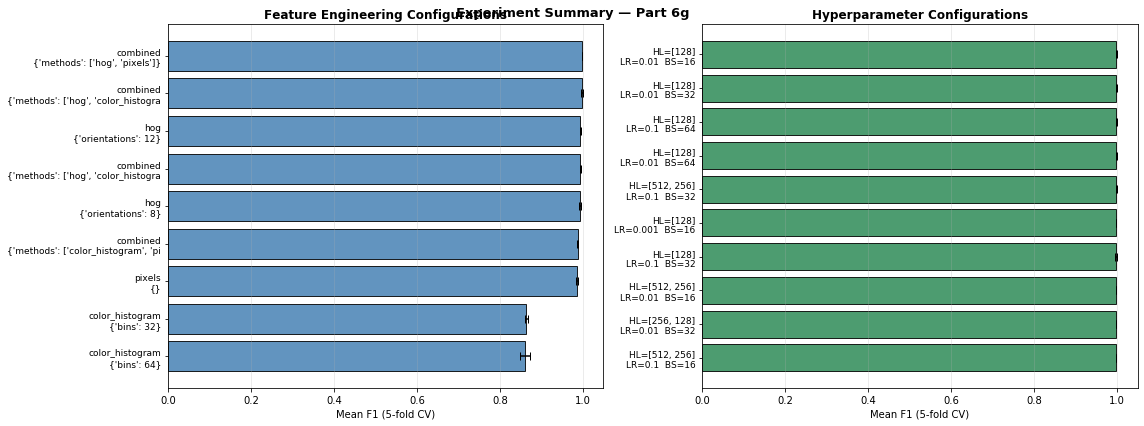

Retraining final model with best config:
  FE : combined  {'methods': ['hog', 'pixels']}
  HP : {'hidden_layers': [128], 'learning_rate': 0.01, 'n_epochs': 50, 'batch_size': 16, 'random_state': 42}


  Epoch  10/50  loss=0.0002
  Epoch  20/50  loss=0.0001
  Epoch  30/50  loss=0.0001
  Epoch  40/50  loss=0.0000
  Epoch  50/50  loss=0.0000


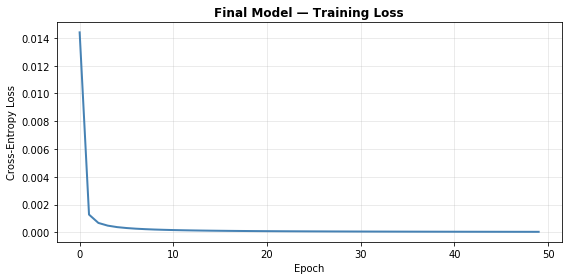


Macro-average F1 score : 0.9961

Per-class classification report:
              precision    recall  f1-score   support

       anime       1.00      1.00      1.00       601
     cartoon       1.00      0.99      0.99       583
       human       1.00      0.99      1.00       600

    accuracy                           1.00      1784
   macro avg       1.00      1.00      1.00      1784
weighted avg       1.00      1.00      1.00      1784



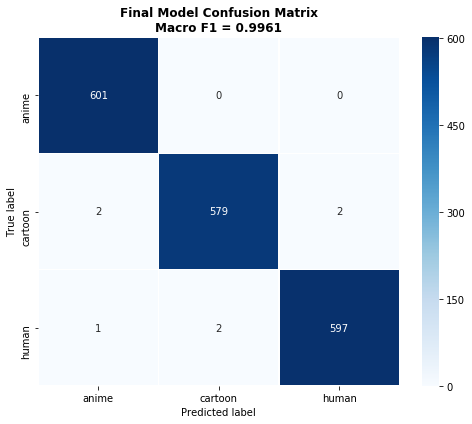

In [40]:
# ── Run Part 6g: plot and retrain ─────────────────────────────────────────────
plot_results(fe_df, hp_df)

best_params = best_hp_config(hp_df, n_epochs=DEFAULT_N_EPOCHS)
print(f"Retraining final model with best config:")
print(f"  FE : {best_method}  {best_fe_params}")
print(f"  HP : {best_params}")

X_tr_final = extract_features(X_train, method=best_method, **best_fe_params)
X_te_final = extract_features(X_test,  method=best_method, **best_fe_params)
X_tr_sc, X_te_sc, _ = preprocess_features(X_tr_final, X_te_final)

final_ann = ANN(**best_params)
final_ann.fit(X_tr_sc, y_train)
final_ann.plot_training_history(title="Final Model — Training Loss")

y_final_pred = final_ann.predict(X_te_sc)
final_f1 = evaluate_model(y_test, y_final_pred, class_info["names"],
                           title="Final Model Confusion Matrix")

---
## Final Summary

In [41]:
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"  Baseline F1  (all features + default ANN) : {baseline_f1:.4f}")
print(f"  Final F1     (best config from Part 6)    : {final_f1:.4f}")
improvement = final_f1 - baseline_f1
print(f"  Improvement                               : {improvement:+.4f}")
print("=" * 60)
print(f"\nBest feature method : {best_method}")
print(f"Best FE params      : {best_fe_params}")
print(f"Best HP params      : {best_params}")

FINAL SUMMARY
  Baseline F1  (all features + default ANN) : 0.9961
  Final F1     (best config from Part 6)    : 0.9961
  Improvement                               : -0.0000

Best feature method : combined
Best FE params      : {'methods': ['hog', 'pixels']}
Best HP params      : {'hidden_layers': [128], 'learning_rate': 0.01, 'n_epochs': 50, 'batch_size': 16, 'random_state': 42}
